# Klasifikasi Spasial Lahan Sawah dan Non-Sawah Menggunakan Citra Sentinel-2A

Bagian ini mendokumentasikan tahapan akuisisi citra satelit optik **Sentinel-2A (Level-2A)** dalam format GeoTIFF (`.tif`) melalui **openEO**, ekstraksi nilai spektral pada **100 titik sampel** (50 sampel Sawah dan 50 sampel Non-Sawah) yang telah dilabeli melalui **QGIS**, hingga pemodelan klasifikasi biner (2 kelas).

## Instalasi Library Yang Digunakan

In [1]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install openeo

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Desain Pengambilan Sampel (Ground Truth)

Pengambilan sampel dilakukan secara spasial dengan membagi objek pengamatan ke dalam dua kelas seimbang (*balanced dataset*) dalam format vektor (`Shapefile` / `GeoJSON`):

| Kelas Target | Kode Label | Jumlah Sampel | Karakteristik Objek |
| :--- | :---: | :---: | :--- |
| **Sawah** | `1` | 50 Sampel | Petak lahan pertanian padi aktif (fase vegetatif, genangan air/tanam, maupun pematangan) |
| **Non-Sawah** | `0` | 50 Sampel | Permukiman/bangunan, jalan raya, badan air permanen, dan vegetasi non-pertanian |
| **Total** | — | **100 Sampel** | Digabungkan menjadi satu *GeoDataFrame* berproyeksi `EPSG:4326` |

In [4]:
import geopandas as gpd
import openeo
import pandas as pd

gdf_sawah = gpd.read_file("sawah.zip").to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file("non-sawah.zip").to_crs("EPSG:4326")

gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0

gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_nonsawah], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah     : {len(gdf_sawah)}")
print(f"Jumlah sampel Non-Sawah : {len(gdf_nonsawah)}")
print(f"Total sampel gabungan   : {len(gdf_gabungan)}")

minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],
    max_cloud_cover=10,
)

composite_s2 = datacube.median_time()

nama_tif = "sentinel2_sawah_nonsawah.tif"
print("Mengunduh citra Sentinel-2A (.tif)...")
composite_s2.download(nama_tif, format="GTiff")
print(f"Berhasil diunduh: {nama_tif}")

Jumlah sampel Sawah     : 50
Jumlah sampel Non-Sawah : 50
Total sampel gabungan   : 100
Bounding Box Gabungan: {'west': 112.38594507662629, 'south': -6.9883535, 'east': 112.4268422, 'north': -6.960227481020833}


Authenticated using refresh token.


Mengunduh citra Sentinel-2A (.tif)...


## 2. Akuisisi Citra Sentinel-2A (`.tif`) via openEO dan Ekstraksi Fitur

Akuisisi citra dilakukan menggunakan *bounding box* gabungan dari ke-100 titik sampel pada koleksi **`SENTINEL2_L2A`** (*Bottom-of-Atmosphere Reflectance*) dengan batas tutupan awan maksimum `< 10%` dan agregasi temporal `median_time()` untuk menghasilkan komposit citra bebas awan berformat **GeoTIFF (`.tif`)**.

### Fitur Spektral dan Indeks Turunan yang Diekstrak:
1. **Band Spektral Utama:**
   * `B02` (*Blue* - 490 nm), `B03` (*Green* - 560 nm), `B04` (*Red* - 665 nm) dengan resolusi spasial 10 meter.
   * `B08` (*Near Infrared / NIR* - 842 nm) untuk mendeteksi pantulan klorofil tanaman padi.
   * `B11` (*Short-Wave Infrared / SWIR* - 1610 nm) untuk mendeteksi kelembapan tanah dan genangan air.
2. **Normalized Difference Vegetation Index (NDVI):**

   $$\text{NDVI} = \frac{B08 - B04}{B08 + B04}$$

3. **Normalized Difference Water Index (NDWI):**

   $$\text{NDWI} = \frac{B03 - B08}{B03 + B08}$$

In [16]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  nilai_band = list(src.sample(koordinat_sampel))

df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

df_dataset.to_csv("dataset_100sampel_sawah_nonsawah.csv", index=False)
print("Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'")
display(df_dataset.head())

fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
print(
    "\n=== HASIL EVALUASI KLASIFIKASI 2 KELAS ==="
)
print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'


C:\Users\faziz\AppData\Local\Temp\ipykernel_16584\2859268898.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
C:\Users\faziz\AppData\Local\Temp\ipykernel_16584\2859268898.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y


,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,492,759,599,2185,1627,0.569684,-0.484375,112.417448,-6.978307,Sawah,1
1,502,777,584,2545,1675,0.626718,-0.532210,112.417374,-6.978740,Sawah,1
2,470,750,581,2743,1688,0.650421,-0.570570,112.417288,-6.979135,Sawah,1
3,464,706,592,2199,1550,0.575779,-0.513941,112.417793,-6.978370,Sawah,1
4,560,795,663,1667,1186,0.430901,-0.354184,112.417716,-6.978880,Sawah,1



=== HASIL EVALUASI KLASIFIKASI 2 KELAS ===
Akurasi Testing : 100.00%

Confusion Matrix:
 [[10  0]
 [ 0 10]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       1.00      1.00      1.00        10
       Sawah       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [17]:
pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


## 3. Hasil Evaluasi Klasifikasi 2 Kelas (Random Forest)

Dataset 100 sampel dibagi menggunakan skema *Stratified Train-Test Split* dengan proporsi **80% Data Latih (80 sampel: 40 Sawah, 40 Non-Sawah)** dan **20% Data Uji (20 sampel: 10 Sawah, 10 Non-Sawah)**.

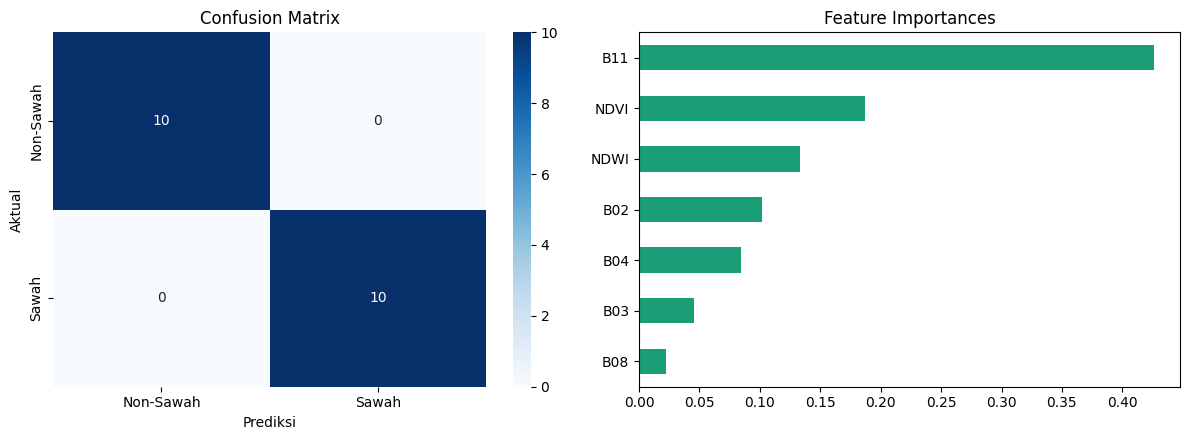

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Non-Sawah', 'Sawah'], yticklabels=['Non-Sawah', 'Sawah'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

imp = pd.Series(model_rf.feature_importances_, index=fitur_kolom).sort_values()
imp.plot(kind='barh', ax=axes[1], color='#1b9e77')
axes[1].set_title('Feature Importances')

plt.tight_layout()
plt.show()

## 4. Peta Klasifikasi Seluruh Citra

Model Random Forest yang telah dilatih diterapkan ke setiap piksel pada citra Sentinel-2A untuk menghasilkan peta klasifikasi spasial secara utuh. Piksel diklasifikasikan menjadi dua kelas: Sawah dan Non-Sawah.

c:\Users\faziz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Persentase Sawah    : 62.5%
Persentase Non-Sawah: 37.5%


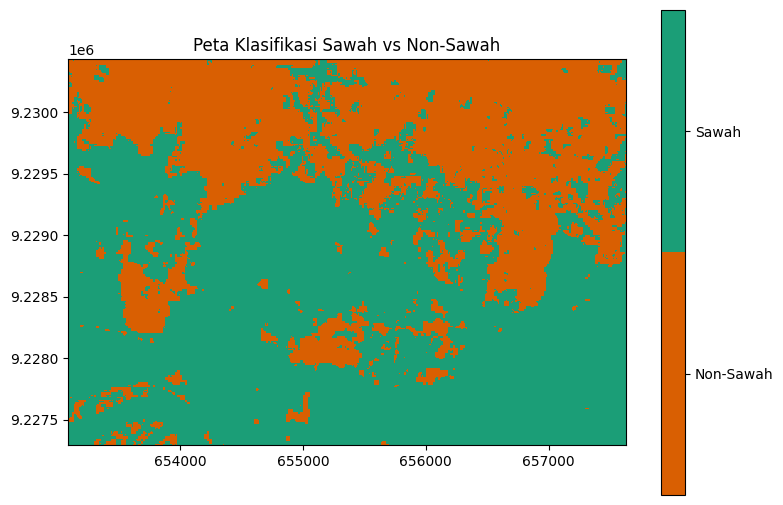

In [20]:
from matplotlib.colors import ListedColormap

with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
    img = src.read()
    ext = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

b02 = img[0].astype(np.float32)
b03 = img[1].astype(np.float32)
b04 = img[2].astype(np.float32)
b08 = img[3].astype(np.float32)
b11 = img[4].astype(np.float32)

ndvi = (b08 - b04) / (b08 + b04 + 1e-6)
ndwi = (b03 - b08) / (b03 + b08 + 1e-6)

fitur_piksel = np.stack([b02, b03, b04, b08, b11, ndvi, ndwi], axis=-1)

h, w, n = fitur_piksel.shape
flat = fitur_piksel.reshape(-1, n)

valid = np.isfinite(flat).all(axis=1)

peta = np.full(h * w, np.nan)

if valid.any():
    preds = model_rf.predict(flat[valid])
    
    # Mapping prediksi: Sawah -> 1.0, Non-Sawah -> 0.0
    preds_int = np.where(preds == 'Sawah', 1.0, 0.0)
    
    peta[valid] = preds_int

peta = peta.reshape(h, w)

print(f"Persentase Sawah    : {np.nanmean(peta == 1.0) * 100:.1f}%")
print(f"Persentase Non-Sawah: {np.nanmean(peta == 0.0) * 100:.1f}%")

# Plot hasil
fig, ax = plt.subplots(figsize=(9, 9))

im = ax.imshow(peta, cmap=ListedColormap(['#d95f02', '#1b9e77']), vmin=0, vmax=1, extent=ext)

cbar = plt.colorbar(im, ax=ax, ticks=[0.25, 0.75], shrink=0.7)
cbar.ax.set_yticklabels(['Non-Sawah', 'Sawah'])
ax.set_title('Peta Klasifikasi Sawah vs Non-Sawah')
plt.show()
